In [2]:
# # _rd_00.py 
# SDL, SRL, simple case 
# 상관관계, 상관계수, 공분산, 산포도. 그룹, 히스토그램 등 회귀분석 전 설명.
# raw data - x: 키, y: 체중, n = 3111 
# mean function in regression. 작업예정... 

import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sci 
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.


In [3]:

# 데이터 파일 읽기. github.com
dat_url = 'https://github.com/bahn28/gamja/blob/main/cs_nns_hgt_wgt.xlsx?raw=true'
df_dat = pd.read_excel(dat_url) 
df_dat.head() 


,x,y
0,174.262367,70.149796
1,166.350641,60.169389
2,158.381596,63.394676
3,163.472285,46.948571
4,157.954485,49.428887


In [4]:
# 1. 데이터 준비. 읽기. 생성. 
n_obs = len(df_dat) 
hgt = df_dat['x'].to_numpy()
wgt = df_dat['y'].to_numpy()
#    gndr = (gndrlit == 'Male').astype(int)   # astype(int)으로 NumPy 배열 전환, 1/0  


# 2. 자료 검토, 요약, 그래프 생성.
# 2a. 자료 검토, 기초 통계량
summ = df_dat.agg(
            ["count", "mean", "std", "min", "median", "max"]
            ) # 일부 변수, 일부 통계량 
# print(summ)
summ.head(7)


,x,y
count,3111.000000,3111.000000
mean,167.076163,63.463587
std,8.599366,12.642302
min,138.146769,20.077826
median,167.040445,63.680696
max,198.211156,106.538459


In [5]:
# 평균점, 분산, 상관계수 
mean_x = hgt.mean()
mean_y = wgt.mean() 
sig_x = hgt.std(ddof=1)
sig_y = wgt.std(ddof=1)
r_xy = np.corrcoef(hgt, wgt)[0,1]  # 상관계수 행렬의 한 원소.
c_xy = np.cov(hgt, wgt)[0, 1]      # 공분산

# SDL, SRL, 준비
b_sdl = (sig_y/sig_x) 
a_sdl = mean_y - b_sdl * mean_x 

b_srl = r_xy*(sig_y/sig_x) 
a_srl = mean_y - b_srl * mean_x 

x_span = np.linspace(130, 200)
y_sdl = a_sdl + b_sdl * x_span 
y_srl = a_srl + b_srl * x_span 

# 키 그룹별 자료 준비.
dat_1 = df_dat[(df_dat['x'] > 155.99) & (df_dat['x'] < 158)] # 밴드 1. 작은 키 소그룹
x_g1 = dat_1['x'] 
y_g1 = dat_1['y'] 
x_g1_mean = x_g1.mean()   # 밴드의 중심
y_g1_mean = y_g1.mean()

dat_2 = df_dat[(df_dat['x'] > 165.99) & (df_dat['x'] < 168)] # 밴드 2. 평균 키 소그룹
x_g2 = dat_2['x'] 
y_g2 = dat_2['y'] 
x_g2_mean = x_g2.mean()   # 밴드의 중심
y_g2_mean = y_g2.mean()

dat_3 = df_dat[(df_dat['x'] > 175.99) & (df_dat['x'] < 178)] # 밴드 3. 큰 키 소그룹
x_g3 = dat_3['x'] 
y_g3 = dat_3['y'] 
x_g3_mean = x_g3.mean()   # 밴드의 중심
y_g3_mean = y_g3.mean()


### 경향
SDL, SRL이 어긋나는 현상(이유)

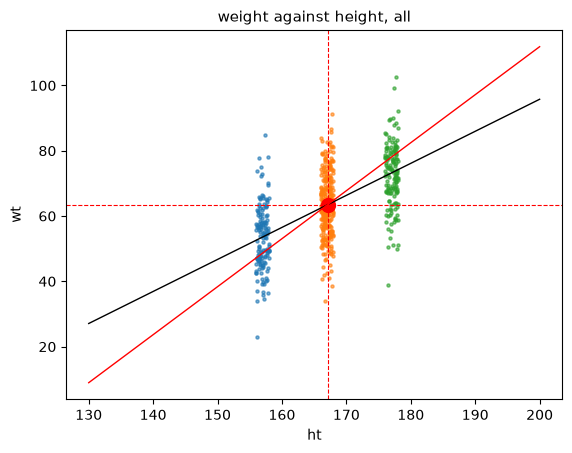

In [11]:
# 그룹별 시각화, (x, y) 관계의 경향 확인
# 산포도 ( x, y )  
plt.figsize=(10, 10)
#    plt.scatter(hgt, wgt, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g1, y_g1, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g2, y_g2, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g3, y_g3, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(mean_x, mean_y, s=100, c='red', marker='o')

#    plt.scatter(x, y, s=10, c='green', marker='o')
plt.plot(x_span, y_srl, color='black', linewidth=1)
plt.plot(x_span, y_sdl, color='red', linewidth=1)
plt.axvline(mean_x, color='red', linestyle='--', lw=0.8)
plt.axhline(mean_y, color='red', linestyle='--', lw=0.8)
plt.title(" weight against height, all ", fontsize=11)
plt.xlabel(" ht ")
plt.ylabel(" wt ")
plt.show()


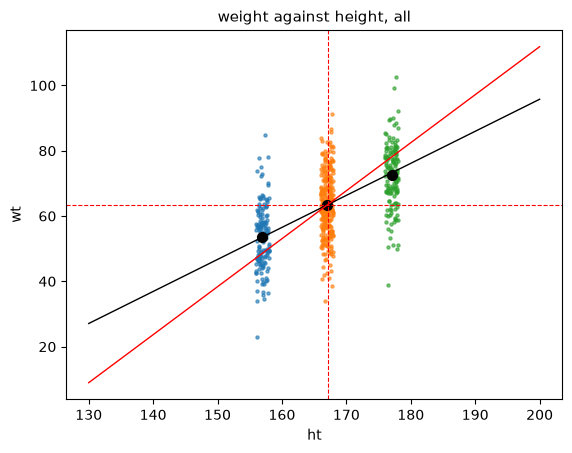

In [12]:
# 그룹별 시각화, (x, y) 관계의 경향 확인
# 산포도 ( x, y )  
plt.figsize=(10, 10)
#    plt.scatter(hgt, wgt, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g1, y_g1, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g2, y_g2, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g3, y_g3, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
# plt.scatter(mean_x, mean_y, s=100, c='red', marker='o')

plt.scatter(x_g1_mean, y_g1_mean, s=50, c='black', marker='o')
plt.scatter(x_g2_mean, y_g2_mean, s=50, c='black', marker='o')
plt.scatter(x_g3_mean, y_g3_mean, s=50, c='black', marker='o')

#    plt.scatter(x, y, s=10, c='green', marker='o')
plt.plot(x_span, y_srl, color='black', linewidth=1)
plt.plot(x_span, y_sdl, color='red', linewidth=1)
plt.axvline(mean_x, color='red', linestyle='--', lw=0.8)
plt.axhline(mean_y, color='red', linestyle='--', lw=0.8)
plt.title(" weight against height, all ", fontsize=11)
plt.xlabel(" ht ")
plt.ylabel(" wt ")
plt.show()


### 개별 띠에서 관측되는 $ y $의 분포

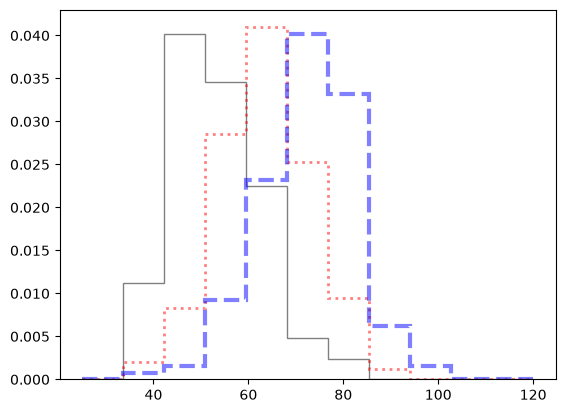

In [7]:
# 소그룹별 y의 특징 확인 
bins = np.linspace(25, 120, 12 ) #15)   # 14개 bin
fig, ax = plt.subplots()
ax.hist(y_g1,
        bins=bins,
        histtype='step',
        color='black',
        #facecolor='none',   # 채우지 않음
        #edgecolor='black', 
        density=True ,
        linewidth=1,
        linestyle = '-',
        alpha=0.5)
ax.hist(y_g2,
        bins=bins,
        histtype='step',
        color='red',
        #facecolor='none',   # 채우지 않음
        #edgecolor='red', 
        linewidth=2,
        linestyle = ':',
        density=True ,
        alpha=0.5)
ax.hist(y_g3,
        bins=bins,
        histtype='step',
        color='blue',
        #facecolor='none',   # 채우지 않음
        #edgecolor='blue', 
        linewidth=3,
        linestyle = '--',
        density=True ,
        alpha=0.5)
    #ax.legend()
plt.show()


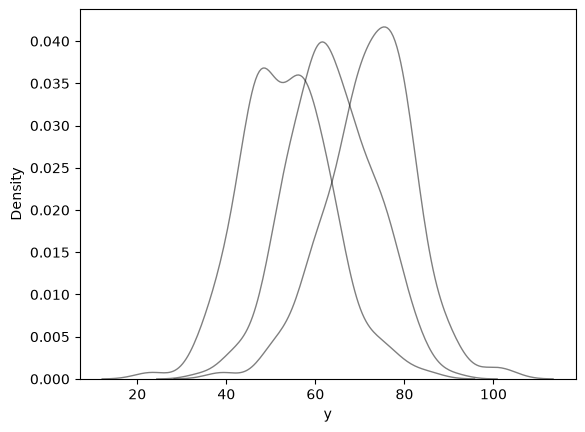

In [8]:
fig, ax = plt.subplots()
sns.kdeplot(y_g1, 
            ax=ax, 
            color='black', 
            linewidth=1, 
            linestyle='-', 
            alpha=0.5)
sns.kdeplot(y_g2, 
            ax=ax, 
            color='black', 
            linewidth=1, 
            linestyle='-', 
            alpha=0.5)
sns.kdeplot(y_g3, 
            ax=ax, 
            color='black', 
            linewidth=1, 
            linestyle='-', 
            alpha=0.5)

plt.show()


Text(0.5, 1.0, ' Subgroup Normal Density (from Mean & SD) ')

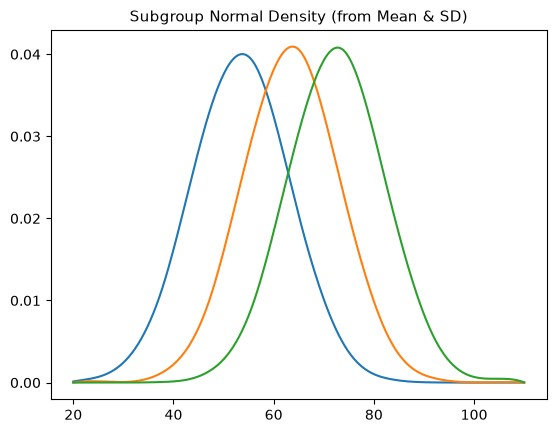

In [14]:

xax = np.linspace(20, 110, 11 ) #15)   # 14개 bin
y1p = stats.norm.pdf(xax, y_g1.mean(), y_g1.std(ddof=1))
y2p = stats.norm.pdf(xax, y_g2.mean(), y_g2.std(ddof=1))
y3p = stats.norm.pdf(xax, y_g3.mean(), y_g3.std(ddof=1))

# 부드럽게 조정하는 아이디어. 중간에 x좌표를 많이 만들고, y를 스플라인 스무스... 
from scipy.interpolate import make_interp_spline
xax_smooth = np.linspace(xax.min(), xax.max(), 300) 
spl = make_interp_spline(xax, y1p, k=3)  # k=3이 부드러운 곡선(스플라인)
y1 = spl(xax_smooth)
spl = make_interp_spline(xax, y2p, k=3)  # k=3이 부드러운 곡선(스플라인)
y2 = spl(xax_smooth)
spl = make_interp_spline(xax, y3p, k=3)  # k=3이 부드러운 곡선(스플라인)
y3 = spl(xax_smooth)

# 2c. 자료 검토, 시각화 확인.
# 산포도 ( x, y )  
fig = plt.figsize=(10, 10)         # 이건 tuple 
#fig = plt.figure(figsize=(10, 8))  # 이건 객체. 
# #    plt.scatter(hgt, wgt, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.plot(xax_smooth, y1  ) # 라인.
plt.plot(xax_smooth, y2  ) #facecolor='none', edgecolor='black')
plt.plot(xax_smooth, y3  ) #facecolor='none', edgecolor='black')
plt.title(" Subgroup Normal Density (from Mean & SD) ", fontsize=11)

